# Trabajo Práctico Final
## Curso de Herramientas para análisis de datos
### Alumna: Valeria Filchtinsky

### 1. Exploración y Transformación de los datos

#### Carga de las bibliotecas y carga del dataset

In [1]:
import pandas as pd
import numpy as np

pd.__version__

'2.2.2'

In [23]:
Dataset=pd.read_excel('/content/sample_-_superstore.xls')

#### Exploración del dataset

In [9]:
dataset.shape

(9994, 21)

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

El dataset contiene 9994 filas y 21 columnas.
No tiene registros nulos.
La columna Row_ID es tipo int(64) correspondiendo a enteros, y la columna Orden_ID que es tipo object, es decir que puede ser texto, parece identificar cada orden de compra.
Las columnas que indican fechas, Orden date y Ship date, tienen el tipo de datos correcto.
La mayoria de las columnas son tipo object, es decir que corresponden a texto.


In [11]:
dataset.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


Las ordenes corresponden a un período de tiempo de 4 años, que va del 03-01-2014 al 30-12-2017.
El valor de venta (sales) abarca un rango muy amplio, de 0,44 a 22638,48. Con una media de 229,85. Y un desvio std alto.
Las cantidades vendidas (quantity) varian entre 1 y 14.  


In [12]:
dataset.duplicated().sum()

np.int64(0)

El dataset no tiene registros duplicados

In [13]:
dataset.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Verifique nuevamente que el datset no incluye valores nulos

Dado que el tipo de dato de cada columna es correcto, y que el dataset no presenta valores nulos ni duplicados, entiendo que ya se encuentra listo para utilizar.

Para facilitar el analisis temporal de las ventas voy a agregar una columna que indique el dia de la semana en que se realizo cada orden y el mes al que corresponde.

In [14]:
dataset["Dia de la semana"] = dataset["Order Date"].dt.day_name()

In [15]:
dias = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

dataset["Dia de la semana"] = dataset["Order Date"].dt.day_name().map(dias)

In [16]:
dataset[["Order Date", "Dia de la semana"]].head()

,Order Date,Dia de la semana
0,2016-11-08,Martes
1,2016-11-08,Martes
2,2016-06-12,Domingo
3,2015-10-11,Domingo
4,2015-10-11,Domingo


Luego de crear la columna con el dia de la semana, la IA me sugirio sentencia para cambiar los nombres a español. Si bien el dataset está en ingles, cambie los nombres de esta columna a español como ejercicio.
Luego verifique como habia quedado visualizando los primeros registros de esa nueva coumna.

In [18]:
dataset["Mes"] = dataset["Order Date"].dt.month

In [19]:
dataset[["Order Date", "Mes"]].head()

,Order Date,Mes
0,2016-11-08,11
1,2016-11-08,11
2,2016-06-12,6
3,2015-10-11,10
4,2015-10-11,10


Agregue columna con el mes de cada venta para luego poder realizar analisis con el mismo. Y comprobe con los primeros registros de esa columna.

Dado que para cada orden cuento con el dato del valor de venta (sales) y de la ganancia (profit). Me parece util crear una columna derivada con el margen de ganancia de cada venta, que seria Margen ganancia= profit / sales.

In [20]:
dataset["Margen de ganancia"] = (dataset["Profit"] / dataset["Sales"]) * 100

In [21]:
dataset[["Sales", "Profit", "Margen de ganancia"]].head()

,Sales,Profit,Margen de ganancia
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [22]:
dataset["Margen de ganancia"].describe()

,Margen de ganancia
count,9994.000000
mean,12.031393
std,46.675435
min,-275.000000
25%,7.500000
50%,27.000000
75%,36.250000
max,50.000000


Verifique la nueva columna construida observando los primeros registros y luego viendo las estadisticas de la misma. Pude observar gran variabilidad de los Margenes de ganancia, con ordenes que tienen margen negativo (pérdida) y valores que van desde el -275% al 50%. Con un margen de ganancia promedio del 12,03%.

### 2. Visualización de los datos

Primero cargo las bibliotecas para realizar gráficos y visualizaciones

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


#### Histograma con Matplotlib que grafica la distribución de las ordenes por Margen de ganancia.

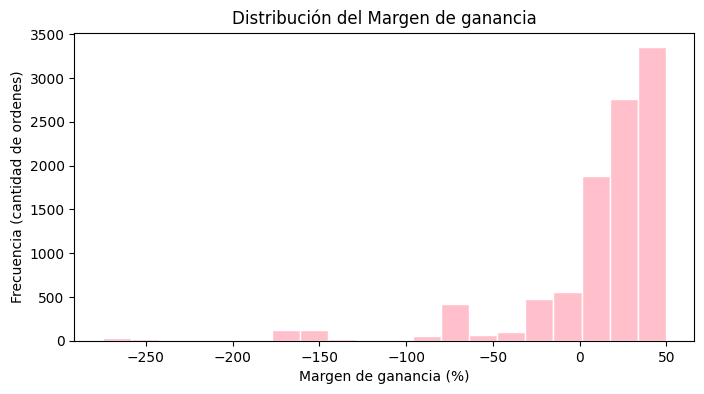

In [27]:
plt.figure(figsize=(8, 4))
plt.hist(dataset["Margen de ganancia"], bins=20, color="pink", edgecolor="white")
plt.title("Distribución del Margen de ganancia")
plt.xlabel("Margen de ganancia (%)")
plt.ylabel("Frecuencia (cantidad de ordenes)")
plt.show()

Del mismo surge que la mayor cantidad de ordenes tienen un Margen de ganancia positivo (>0). La cantidad de ordenes aumenta al acercarse a 50% que representa el máximo de Margen de ganancia.

#### Grafico de un boxplot de la columna Margen de ganancia

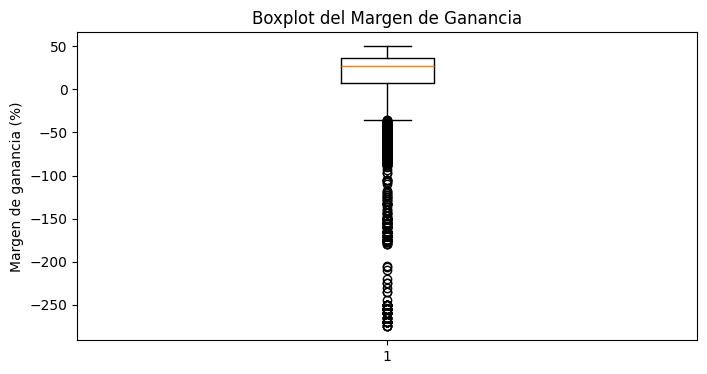

In [31]:
plt.figure(figsize=(8, 4))

plt.boxplot(dataset["Margen de ganancia"])
plt.title("Boxplot del Margen de Ganancia")
plt.ylabel("Margen de ganancia (%)")
plt.show()

En el boxplot se observa que el margen de ganancia tiene principalmente valores positivos, con una mediana cercana al 25%. Sin embargo, se observan una gran cantidad de valores atípicos negativos, algunos inferiores al -100%. La distribución presenta una marcada asimetría hacia valores negativos.

#### Gráfico con cantidad de ordenes según el dia de la semana utilizando seaborn

/tmp/ipykernel_820/227881080.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


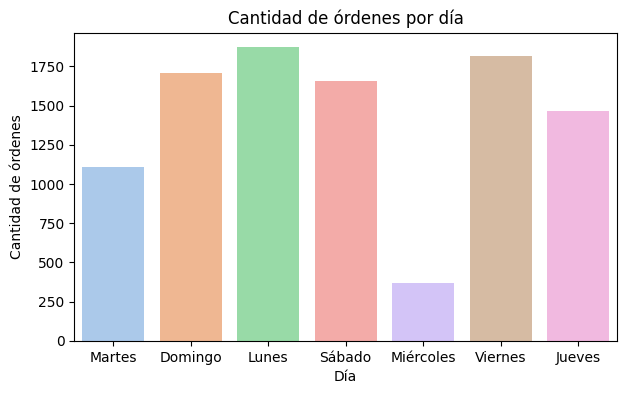

In [33]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=dataset,
    x="Dia de la semana",
    palette="pastel"
)

plt.title("Cantidad de órdenes por día")
plt.xlabel("Día")
plt.ylabel("Cantidad de órdenes")
plt.show()

/tmp/ipykernel_820/2731284025.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


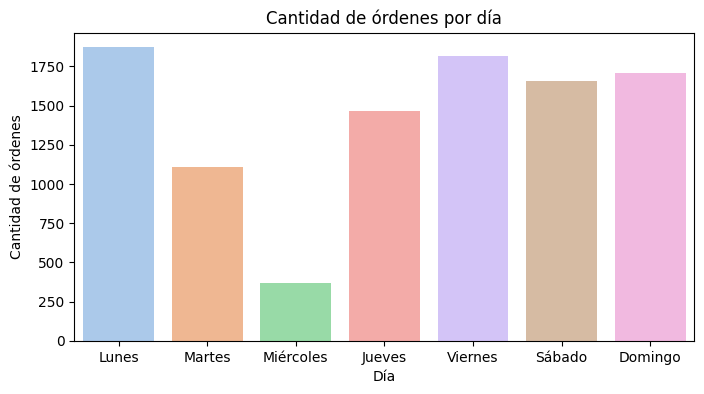

In [34]:
orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

plt.figure(figsize=(8, 4))

sns.countplot(
    data=dataset,
    x="Dia de la semana",
    order=orden_dias,
    palette="pastel"
)

plt.title("Cantidad de órdenes por día")
plt.xlabel("Día")
plt.ylabel("Cantidad de órdenes")
plt.show()

Le pedi a la IA que me indique como hacer que los dias de la semana aparezcan ordenados, y me sugirio indicar el orden exacto usando el parametro "order".
De esta manera los dias del eje x aparecen en el orden deseado.

En el gráfico se observa que la cantidad de ordenes presenta una gran variación según el dia de la semana.
El lunes concentra la mayor cantidad de órdenes, seguido por el viernes, mientras que el miércoles presenta una cantidad considerablemente menor. Durante el fin de semana se observa nuevamente un nivel elevado de órdenes, especialmente el domingo.
Esto sugiere que la actividad de compra no se distribuye uniformemente a lo largo de la semana, con una fuerte concentración los lunes y hacia el final de la semana

#### Gráfico que relacione Valor de venta y Margen de ganancia



Para analizar si existe una relación entre el Valor de ventas en $ y el Margen de ganancias (%), realizaré un gráfico de dicha correlación

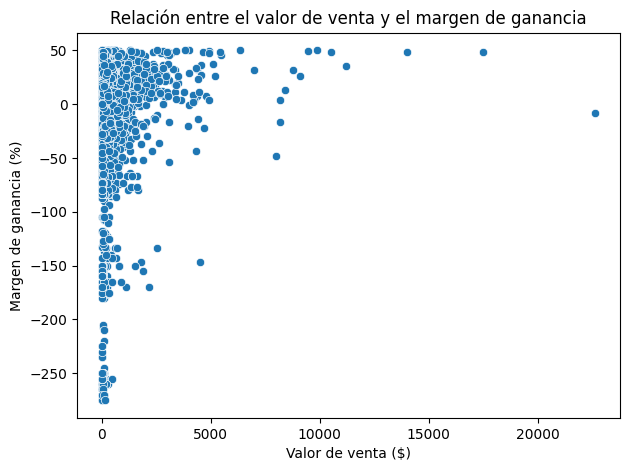

In [36]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=dataset,
    x="Sales",
    y="Margen de ganancia"
)

plt.title("Relación entre el valor de venta y el margen de ganancia")
plt.xlabel("Valor de venta ($)")
plt.ylabel("Margen de ganancia (%)")
plt.show()

El gráfico muestra una gran concentración de ventas de bajo valor, principalmente inferiores a $5.000. La mayoría de estas operaciones presenta márgenes positivos, generalmente entre 0% y 50%, aunque también se observan numerosas ventas con márgenes negativos y algunos valores extremos inferiores al -100%.
Parecería que a medida que aumenta el valor de las ventas, disminuye la presencia de márgenes extremadamente negativos. Sin embargo, la dispersión de los puntos indica que el valor de la venta por sí solo no explica completamente el margen de ganancia.

Para verificar lo anterior calculo el coeficiente de correlación de Pearson, que permite medir la relación lineal entre dos variables.

In [37]:
correlacion = dataset["Sales"].corr(dataset["Margen de ganancia"])

print(correlacion)

0.0034440325683031923


El valor del coeficiente cercano a 0 indica que hay poca o ninguna relación entre las variables.